# Ejercicio de clase: Predicción del precio de vivienda con Decision Tree Regressor

**Dataset**: California Housing Prices — https://www.kaggle.com/datasets/camnugent/california-housing-prices

En el ejemplo de clase (`decision_tree_example.ipynb`) usamos un **Decision Tree Classifier** para predecir
si un paciente sobrevivía o no a una sepsis. Esa era una tarea de **clasificación**: la variable que
queríamos predecir (`hospital_outcome`) solo podía tomar un número limitado de valores (0 o 1, "vive" o
"muere").

En este ejercicio vamos a resolver un problema distinto: **regresión**. Vamos a predecir el **precio
mediano de una vivienda** (`median_house_value`) en un bloque censal de California, a partir de
características como la ubicación, la cantidad de habitaciones o el ingreso medio de sus habitantes.

> **Diferencia clave**: en clasificación el modelo predice una *categoría* (una clase). En regresión el
> modelo predice un *número real* (puede tomar, en principio, cualquier valor dentro de un rango continuo).
> Esto tiene consecuencias importantes: no podemos usar métricas como *precision*, *recall* o *F1*, porque
> esas métricas comparan clases exactas. En su lugar usaremos métricas que midan **qué tan lejos** está la
> predicción del valor real, como el **MAE (Mean Absolute Error)**, que veremos más adelante.

Para este ejercicio usarán `DecisionTreeRegressor` en lugar de `DecisionTreeClassifier`.

### Antes de empezar

1. Descarguen el dataset desde Kaggle: https://www.kaggle.com/datasets/camnugent/california-housing-prices
2. El archivo se llama `housing.csv`. Colóquenlo dentro de la carpeta `raw/` de este proyecto
   (la misma carpeta `decision_tree/raw/` donde está el dataset de sepsis).
3. Sigan cada sección en orden. Cada sección tiene:
   - Una breve explicación de qué vamos a hacer y por qué.
   - Un **reto**: ustedes deben escribir el código (no está resuelto).
   - **Preguntas de análisis**: respóndanlas en una celda de markdown justo debajo de su código.


### Importar librerías

Igual que en el ejemplo de clase, empezamos importando las librerías que vamos a necesitar. Noten dos
diferencias frente al ejemplo de clasificación:

- Usamos `DecisionTreeRegressor` en lugar de `DecisionTreeClassifier`.
- Usamos `mean_absolute_error` en lugar de `precision_score`, `recall_score`, `f1_score`.


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

## Paso 1 — Cargar los datos

**Reto**: Carguen el archivo `housing.csv` (carpeta `raw/`) en un DataFrame de pandas llamado `df`, tal
como hicimos en el ejemplo de clase con `pd.read_csv(...)`. Luego muestren las primeras filas del
DataFrame para confirmar que se cargó correctamente.


In [3]:
from pathlib import Path

housing_path = Path("raw/housing.csv")
housing_url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(housing_path if housing_path.exists() else housing_url)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df.head()

**Preguntas de análisis**
1. ¿Cuántas filas y cuántas columnas tiene el dataset? (pista: `df.shape`)
2. ¿Qué representa cada fila del dataset? ¿Es una vivienda individual o algo distinto?
3. Observando los nombres de las columnas, ¿cuál creen que es la variable que vamos a predecir (el *target*)?

**Respuestas**
1. El dataset tiene 20.640 filas y 10 columnas.
2. Cada fila representa un bloque censal de California, no una vivienda individual. Por eso las variables describen valores agregados del bloque, como el número total de habitaciones o la población.
3. El target es `median_house_value`, el precio mediano de las viviendas del bloque.

## Paso 2 — Identificación inicial de los datos

Antes de tocar cualquier dato, siempre debemos entender con qué estamos trabajando: cuántas columnas hay,
qué tipo de dato tiene cada una, si hay valores nulos, y cuál es el rango de valores de cada variable.

**Reto**: Usando lo que ya conocen de pandas, respondan (con código) estas tres preguntas:
1. ¿Qué tipo de dato (`dtype`) tiene cada columna? ¿Hay alguna columna categórica (texto)?
2. ¿Cuáles son las estadísticas básicas (media, desviación estándar, mínimo, máximo, etc.) de las
   columnas numéricas?
3. ¿Hay valores nulos (faltantes) en el dataset? ¿En qué columna(s)?

Pistas de los métodos que necesitan (ya los usamos, en otra forma, en el ejemplo de clase): `.info()`,
`.describe()`, `.isnull()`.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

**Preguntas de análisis**
1. ¿Cuál es la única columna categórica (de texto) del dataset? ¿Qué valores puede tomar?
2. ¿Qué columna tiene valores nulos? ¿Cuántas filas están afectadas, aproximadamente qué porcentaje del total representa?
3. Miren el `min` y el `max` de `median_house_value`. ¿Les parece un rango razonable para el precio de una vivienda? ¿Notan algo raro en el valor máximo? (pista: busquen cuántas filas tienen exactamente ese valor máximo).
4. Comparen el rango de `median_income` con el de `total_rooms`. ¿Están en escalas muy distintas? ¿Creen que eso sería un problema para un Decision Tree? (piensen en cómo el árbol elige los cortes: ¿necesita que las variables estén en la misma escala, como sí lo necesitan otros modelos?)

**Respuestas**
1. La única columna categórica es `ocean_proximity`. Sus valores son `INLAND`, `<1H OCEAN`, `NEAR OCEAN`, `NEAR BAY` e `ISLAND`.
2. `total_bedrooms` tiene 207 valores nulos, aproximadamente el 1,00% de las 20.640 filas.
3. `median_house_value` va de 14.999 a 500.001 dólares. El máximo resulta sospechoso porque hay 965 filas exactamente con ese valor, lo que indica un tope de medición o censura, no necesariamente un precio real exacto.
4. Sí, están en escalas muy distintas: `median_income` va aproximadamente de 0,50 a 15,00, mientras `total_rooms` va de 2 a 39.320. Esto no es un problema importante para un árbol, porque sus cortes dependen del orden y de umbrales de cada variable; no exige normalización o estandarización.

## Paso 3 — Procesamiento de datos

Por ahora, para mantener el ejercicio simple, vamos a trabajar **solo con variables numéricas**. Más
adelante en el curso aprenderemos técnicas para incorporar variables categóricas (como *one-hot encoding*),
pero hoy las vamos a descartar.

**Reto**:
1. Eliminen del DataFrame la(s) columna(s) categórica(s) que identificaron en el paso anterior.
2. Decidan qué hacer con los valores nulos que encontraron (por ejemplo, eliminar esas filas) y
   apliquen esa decisión. Un Decision Tree Regressor de scikit-learn no puede entrenarse si quedan
   valores `NaN` en los datos.
3. Confirmen, con código, que ya no quedan columnas categóricas ni valores nulos.


In [7]:
df_num = df.drop(columns=["ocean_proximity"]).copy()
df_num.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0


In [8]:
df_num = df_num.dropna().copy()
print("Filas originales:", len(df))
print("Filas despues de eliminar nulos:", len(df_num))
print("Filas eliminadas:", len(df) - len(df_num))

Filas originales: 20640
Filas despues de eliminar nulos: 20433
Filas eliminadas: 207


In [9]:
print("Columnas de texto:", df_num.select_dtypes(include="object").columns.tolist())
print("Nulos por columna:")
print(df_num.isnull().sum())

Columnas de texto: []
Nulos por columna:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


**Preguntas de análisis**
1. ¿Qué información de las viviendas estamos perdiendo al eliminar la columna categórica? ¿Creen que esa información podría ser útil para predecir el precio? ¿Por qué?
2. Si eliminaron filas con nulos, ¿cuántas filas quedaron en total? ¿Qué porcentaje del dataset original se perdió?
3. ¿Qué otra estrategia (distinta a eliminar las filas) existe para tratar valores nulos? ¿Por qué hoy optamos por la más simple?

**Respuestas**
1. Perdemos la ubicación relativa al océano (`ocean_proximity`). Esa información puede ser muy útil porque la cercanía a la costa o a la bahía suele influir en el precio. Para usarla habría que codificarla, por ejemplo mediante one-hot encoding.
2. Quedaron 20.433 filas. Se perdieron 207, es decir, aproximadamente el 1,00% del dataset original.
3. Se pueden imputar los valores, por ejemplo usando la mediana de `total_bedrooms`, o utilizar un imputador de scikit-learn dentro de un pipeline. Hoy eliminamos las filas porque es la estrategia más simple y la proporción faltante es pequeña.

## Paso 4 — Definir variables predictoras (X) y variable objetivo (y), y dividir los datos

Igual que en el ejemplo de clase, necesitamos separar:
- **X**: las columnas que el modelo usará para predecir (todas menos el precio).
- **y**: la columna que queremos predecir (`median_house_value`).

Y luego dividir ambas en un conjunto de **entrenamiento** y uno de **prueba**, usando
`train_test_split`, tal como hicimos con los datos de sepsis.

**Reto**:
1. Construyan `X` (todas las columnas numéricas excepto `median_house_value`) y `y`
   (`median_house_value`).
2. Usen `train_test_split` para crear `X_train`, `X_test`, `y_train`, `y_test`. Usen un `test_size` de
   0.2 y `random_state=0` para que los resultados sean reproducibles.


In [10]:
X = df_num.drop(columns=["median_house_value"])
y = df_num["median_house_value"]

print("X:", X.shape)
print("y:", y.shape)

X: (20433, 8)
y: (20433,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (16346, 8)
X_test: (4087, 8)


**Preguntas de análisis**
1. ¿Cuántas filas quedaron en `X_train` y cuántas en `X_test`?
2. ¿Por qué es importante evaluar el modelo en datos que **no** usó para entrenar (`X_test`, `y_test`)? ¿Qué pasaría si evaluáramos únicamente sobre `X_train`?
3. En el ejemplo de clase balanceamos las clases con SMOTE antes de dividir los datos. Aquí no lo hicimos. ¿Por qué SMOTE (que genera ejemplos sintéticos de una *clase* minoritaria) no tiene sentido en un problema de regresión, donde no hay clases sino un valor continuo?

**Respuestas**
1. `X_train` tiene 16.346 filas y `X_test` tiene 4.087.
2. El conjunto de prueba permite estimar la capacidad de generalización sobre datos no vistos. Si evaluáramos solo sobre `X_train`, el resultado podría ser demasiado optimista, especialmente porque un árbol profundo puede memorizar los ejemplos de entrenamiento.
3. SMOTE está diseñado para crear observaciones de una clase minoritaria en clasificación. En regresión no existen clases discretas que balancear; el objetivo es continuo. Para una distribución continua se usarían otras técnicas, como ponderación, muestreo o métodos específicos de aumento de datos.

## Paso 5 — Entrenar el Decision Tree Regressor

**Reto**: Entrenen un `DecisionTreeRegressor` (con `random_state=0`) usando `X_train` y `y_train`, de la
misma forma en que entrenaron el `DecisionTreeClassifier` en el ejemplo de clase.


In [12]:
reg = DecisionTreeRegressor(random_state=0)
reg.fit(X_train, y_train)
print("Modelo entrenado")

Modelo entrenado


**Preguntas de análisis**
1. En clasificación, cada hoja del árbol predice una clase (por ejemplo, "vive" o "muere"). En regresión, ¿qué creen que predice cada hoja del árbol? (pista: piensen en los valores de `y` que caen en esa hoja durante el entrenamiento).
2. ¿Qué criterio usa por defecto `DecisionTreeRegressor` para decidir dónde hacer cada corte, en lugar del *gini* o *entropy* que se usan en clasificación? (revisen la documentación del parámetro `criterion`).

**Respuestas**
1. Cada hoja predice un valor numérico, normalmente la media de los valores de `y` de las muestras de entrenamiento que llegan a esa hoja.
2. Usa `squared_error` por defecto, que busca reducir el error cuadrático medio (MSE) dentro de los nodos. En clasificación se usan criterios como Gini o entropía porque allí se separan clases.

## Paso 6 — Evaluar el modelo con MAE

### ¿Qué es el MAE (Mean Absolute Error)?

El **MAE** es el promedio de la diferencia absoluta entre el valor real y el valor predicho:

$$MAE = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|$$

A diferencia de precision/recall/F1 (que solo tienen sentido cuando comparamos clases), el MAE funciona
sobre valores numéricos continuos y nos dice, **en promedio, cuánto se equivoca el modelo, en las mismas
unidades que la variable objetivo**. En nuestro caso, como `median_house_value` está en dólares, un
MAE de, por ejemplo, 40000 significa que en promedio el modelo se equivoca en $40,000 dólares al predecir
el precio de una vivienda.

Un MAE más bajo es mejor. Pero un mismo valor de MAE puede ser "bueno" o "malo" dependiendo de la escala
de la variable que estamos prediciendo — por eso siempre hay que compararlo contra algo (por ejemplo,
el precio promedio de las viviendas).

**Reto**:
1. Usen el modelo entrenado para predecir sobre `X_train` y calculen el MAE comparando esas predicciones
   con `y_train`.
2. Hagan lo mismo sobre `X_test` con `y_test`.
3. Comparen ambos valores.


In [13]:
y_train_pred = reg.predict(X_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
print("MAE (train):", mae_train)

MAE (train): 0.0


In [14]:
y_test_pred = reg.predict(X_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
print("MAE (test):", mae_test)

MAE (test): 43557.103743577194


**Preguntas de análisis**
1. ¿El MAE de entrenamiento es mayor, menor o similar al MAE de prueba? ¿Qué les dice eso sobre qué tan bien "memorizó" el árbol los datos de entrenamiento?
2. Calculen el precio promedio (`.mean()`) de `median_house_value` en todo el dataset. Comparando ese promedio con el MAE de prueba, ¿el error del modelo les parece grande o pequeño en proporción al precio típico de una vivienda?
3. En el ejemplo de clase, un árbol sin restricciones (`fully grown`) mostraba señales de sobreajuste (*overfitting*) al compararlo con un árbol más simple (`max_depth=3`). Según los MAE de train y test que obtuvieron, ¿creen que este árbol también está sobreajustado? ¿Por qué?

**Respuestas**
1. El MAE de entrenamiento es 0 dólares y el de prueba es aproximadamente 43.557 dólares. La diferencia muestra que el árbol completamente desarrollado memoriza prácticamente todos los ejemplos de entrenamiento.
2. El precio medio es aproximadamente 206.856 dólares. El MAE de prueba representa cerca del 21% de ese valor, por lo que es un error relevante, aunque razonable para un modelo básico que no usa la variable categórica ni imputación más elaborada.
3. Sí, hay señales claras de sobreajuste: el error de entrenamiento es nulo, mientras que el error sobre datos nuevos es mucho mayor. El árbol está aprendiendo reglas muy específicas del conjunto de entrenamiento.

## Reto adicional (opcional) — ¿Se puede mejorar el árbol?

En el ejemplo de clase, limitar la profundidad del árbol (`max_depth=3`) cambió el comportamiento del modelo. Prueben lo mismo aquí:

1. Entrenen un segundo `DecisionTreeRegressor`, esta vez fijando `max_depth` (prueben con distintos valores, por ejemplo 3, 5, 10).
2. Calculen el MAE de train y de test para cada valor de `max_depth`.
3. Grafiquen (opcional) el MAE de train y de test contra `max_depth`, como una curva.

**Preguntas de análisis**
1. ¿Qué le pasa al MAE de entrenamiento a medida que aumentan `max_depth`? ¿Y al de prueba?
2. ¿Existe un valor de `max_depth` donde el MAE de prueba deja de mejorar (o empeora)? ¿Qué relación tiene eso con el concepto de *overfitting* que vimos en el ejemplo de clase?
3. Miren `reg.feature_importances_` del árbol entrenado. ¿Cuáles son las 2 o 3 variables más importantes para predecir el precio de la vivienda? ¿Tiene sentido con lo que ustedes esperarían intuitivamente?

**Respuestas**
1. El MAE de entrenamiento disminuye al aumentar la profundidad: aproximadamente 60.960 (`3`), 52.175 (`5`), 31.093 (`10`) y 0 en el árbol sin límite. El MAE de prueba también baja hasta `max_depth=10`: aproximadamente 61.405, 54.349, 40.590 y 43.557, respectivamente.
2. En esta prueba, `max_depth=10` obtiene el menor MAE de prueba. Al pasar a un árbol sin límite, el MAE de entrenamiento sigue bajando hasta cero, pero el de prueba empeora, una señal de sobreajuste.
3. Las variables más importantes son `median_income` (aprox. 0,514), `longitude` (0,171) y `latitude` (0,160). Es razonable: el ingreso y la ubicación suelen estar fuertemente relacionados con el precio de la vivienda.

  max_depth     mae_train      mae_test
0         3  60959.983597  61404.840790
1         5  52174.938951  54349.267723
2        10  31093.303914  40589.700618
3      None      0.000000  43557.103744

Importancia de variables:
median_income         0.513873
longitude             0.171168
latitude              0.159964
housing_median_age    0.063234
population            0.029061
total_bedrooms        0.026500
households            0.018488
total_rooms           0.017712
dtype: float64


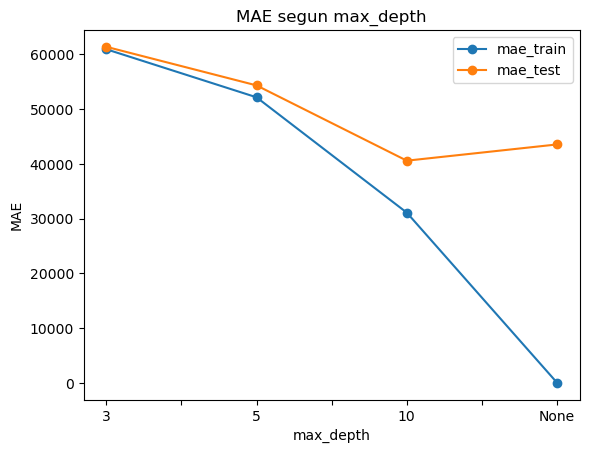

In [16]:
depth_results = []
for depth in [3, 5, 10, None]:
    depth_model = DecisionTreeRegressor(max_depth=depth, random_state=0)
    depth_model.fit(X_train, y_train)
    depth_results.append({
        "max_depth": depth if depth is not None else "None",
        "mae_train": mean_absolute_error(y_train, depth_model.predict(X_train)),
        "mae_test": mean_absolute_error(y_test, depth_model.predict(X_test)),
    })

depth_results = pd.DataFrame(depth_results)
print(depth_results)

importance = pd.Series(reg.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nImportancia de variables:")
print(importance)

ax = depth_results.plot(x="max_depth", y=["mae_train", "mae_test"], marker="o")
ax.set_ylabel("MAE")
ax.set_title("MAE segun max_depth")
plt.show()